# Практическая работа № 2

**Цель работы:** познакомиться с базовыми архитектурами нейронных сетей: полносвязной (FCNN), рекуррентной (RNN) и сверточной (CNN). Изучить, для каких типов данных каждая из них подходит лучше.

**Задачи:**

1. Построить и обучить модели на трех датасетах с разными типами данных
2. Проанализировать процесс обучения с помощью графиков функции потерь
3. Оценить качество моделей с помощью метрик
4. Провести эксперименты с гиперпараметрами
5. Сделать выводы по каждой модели и общий вывод

---

**Теоретическая справка**

**Нейронная сеть** состоит из слоев нейронов, каждый из которых выполняет преобразование входных данных.

В данной работе рассматриваются три архитектуры нейронных сетей, каждая из которых предназначена для обработки определённого типа данных:
* FCNN — для табличных данных
* RNN — для последовательностей (временные ряды)
* CNN — для изображений

**1. Полносвязная нейронная сеть (Fully Connected Neural Network)** состоит из последовательности слоёв, где каждый нейрон связан со всеми нейронами следующего слоя. Структура: входной слой (признаки), несколько скрытых слоёв, выходной слой. Простая и универсальная, не учитывает структуру данных, работает только с вектором признаков. Будем использовать для решения задачи многоклассовой классификации.

* Активация: ReLU — в скрытых слоях, Softmax — на выходе (для многоклассовой классификации)
* Функция потерь: CrossEntropyLoss
* Оптимизатор: Adam
* Существующие модели: классические MLP (Multi-Layer Perceptron), глубокие fully-connected сети

**2. Рекуррентная нейронная сеть (RNN)** предназначена для обработки последовательностей. В отличие от FCNN, она учитывает предыдущие значения. Будем решать задачу прогнозирования (регрессия).

* Активация: tanh (внутри RNN), ReLU (в dense слое после RNN)
* Функция потерь: MSE
* Оптимизатор: Adam
* Вариации RNN: LSTM — решает проблему забывания, GRU — упрощённая версия

**3. Сверточная нейронная сеть (CNN)** использует свертки для обработки данных с пространственной структурой. Основные компоненты:
* Сверточный слой (Conv2D) извлекает признаки (границы, текстуры).
* Функция активации (ReLU) добавляет нелинейность.
* Pooling слой уменьшает размер изображения.
* Fully Connected слой — финальная классификация.

Будем решать задачу классификации изображений.

* Выход: Softmax
* Функция потерь: CrossEntropyLoss
* Оптимизатор: Adam
* Существующие модели: LeNet, AlexNet, VGG, ResNet

---



**Используемые инструменты**

* PyTorch — для построения и обучения нейронных сетей, а также автоматического вычисления градиентов
* NumPy — для работы с массивами и предварительной обработки данных
* Pandas — для загрузки и анализа табличных данных (например, в датасетах Dry Bean и Air Quality)
* Matplotlib / Seaborn — для визуализации результатов обучения (графики функции потерь, метрики качества)
* Scikit-learn — для разбиения данных на обучающую и тестовую выборки, вычисления метрик качества моделей

In [ ]:
# Используемые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms, models
import os
import torch.nn.functional as F

## 1. Выбор датасетов

**1.**
Для полносвязной нейронной сети (FCNN) был выбран Dry Bean Dataset, так как он представляет собой классический пример табличных данных с числовыми признаками:
https://www.kaggle.com/datasets/sansuthi/dry-bean-dataset

Датасет содержит информацию о зёрнах фасоли различных сортов. Каждый объект представляет собой одно зерно, описанное набором геометрических характеристик, полученных после обработки изображений.

Все признаки являются числовыми и отражают форму и размеры зерна:
* площадь (Area)
* периметр (Perimeter)
* длина и ширина
* компактность (Compactness)
* коэффициенты формы

Целевой переменной для задачи классификации является сорт фасоли — категориальная переменная с несколькими классами.

**2.**
Для рекуррентной нейронной сети (RNN) был выбран датасет UCI Air Quality Dataset, так как он содержит временные данные, где каждое наблюдение зависит от предыдущих:
https://www.kaggle.com/datasets/dakshbhalala/uci-air-quality-dataset

Датасет содержит измерения качества воздуха, собранные с датчиков в течение длительного периода времени.

Признаки:
* концентрации загрязняющих веществ: CO, NO2,NOx, бензол
* погодные параметры: температура, влажность
* временные признаки: дата, время

Будем использовать задачу регрессии — прогноз значения одного из показателей (например, CO).

**3.**
Для сверточной нейронной сети (CNN) был выбран датасет Apple Leaf Disease Dataset, так как он содержит изображения, что является основным типом данных для данной архитектуры: https://www.kaggle.com/datasets/nirmalsankalana/apple-leaf-disease-dataset

Датасет содержит изображения листьев яблони, поражённых различными заболеваниями, а также изображения здоровых листьев. Данные организованы в виде папок, где каждая соответствует определённому классу.

Классы:
* healthy
* scab
* rust

Задача — классификация изображений по классу.

## 3. FCNN

### Подготовка данных

Для полносвязной сети нужна нормализация. Признаки (площадь, периметр) имеют разные единицы измерения и масштабы, приведем к одному виду. Целевую переменную (Bean Type) переведем в числа 0-6.

In [ ]:
df = pd.read_csv('Dry_Bean.csv')

# Кодирование целевой переменной в числа
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])

X = df.drop('Class', axis=1).values
y = df['Class'].values

# Нормализация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Перевод в тензоры PyTorch
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.LongTensor(y_test)

# Создание DataLoader для обучения батчами
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

Подготовили данные и перевели в тензоры, чтобы PyTorch мог провести математические операции внутри нейронов. Для признаков использовали Float, для меток классов Long (целые числа), так как это номера категорий.

Так как в датасете тысячи строк, если подать их модели все сразу, обучение будет долгим и менее эффективным. Поэтому использовали DataLoader, который разбивает данные на батчи (в данном случае по 64). Это делает обучение стабильным и быстрым.

Посмотрим распределение целевой переменной.

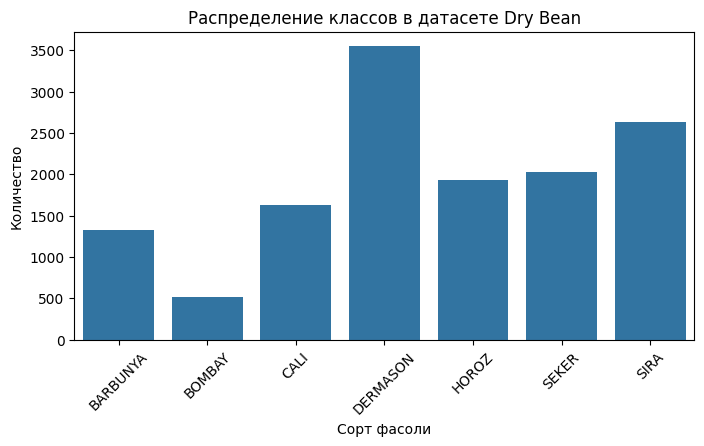

In [ ]:
plt.figure(figsize=(8, 4))
sns.countplot(x=df['Class'])
plt.title('Распределение классов в датасете Dry Bean')
plt.xlabel('Сорт фасоли')
plt.ylabel('Количество')
plt.xticks(ticks=range(7), labels=le.classes_, rotation=45)
plt.show()

На графике видно, что классы распределены неравномерно. Такой дисбаланс не является критическим, но модели будет проще выучить признаки наиболее часто встречающихся сортов.

### Архитектура модели

Готовых моделей для простых табличных данных в библиотеках практически нет, поэтому создадим базовую модель с двумя скрытыми слоями. На вход она принимает 16 признаков (столько их в Dry Bean), а на выходе выдает 7 чисел (количество сортов фасоли).

In [ ]:
class FCNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(FCNNModel, self).__init__()
        # Первый слой: от входных признаков к скрытому слою
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Второй слой: уменьшаем количество нейронов
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        # Выходной слой: к количеству классов
        self.fc3 = nn.Linear(hidden_dim // 2, output_dim)

        # Функции активации
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Определяем параметры
input_size = X_train.shape[1] # 16
hidden_size = 64
output_size = len(le.classes_) # 7

model = FCNNModel(input_size, hidden_size, output_size)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

FCNNModel(
  (fc1): Linear(in_features=16, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=7, bias=True)
  (relu): ReLU()
)


Модель состоит из входного слоя, двух скрытых слоев с функцией активации ReLU и выходного слоя. Количество нейронов в скрытых слоях выбрано 64 и 32 для обеспечения достаточной емкости модели при сохранении скорости обучения. Функция потерь CrossEntropyLoss, оптимизатор Adam.

### Цикл обучения и построение графика Loss

Теперь обучим модель и построим график функции потерь.

Epoch [5/30], Loss: 0.2032
Epoch [10/30], Loss: 0.1921
Epoch [15/30], Loss: 0.1845
Epoch [20/30], Loss: 0.1840
Epoch [25/30], Loss: 0.1793
Epoch [30/30], Loss: 0.1760


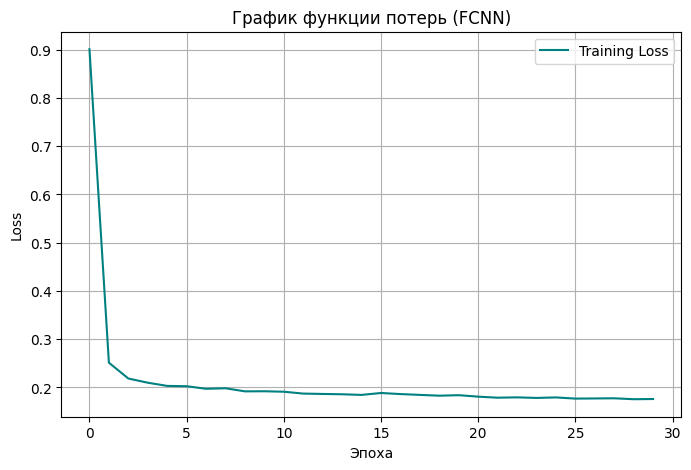

In [ ]:
epochs = 30
history_loss = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        optimizer.zero_grad()       # Обнуляем градиенты
        outputs = model(inputs)     # Прямой проход
        loss = criterion(outputs, labels) # Вычисление ошибки
        loss.backward()             # Обратный проход (градиенты)
        optimizer.step()            # Обновление весов

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    history_loss.append(epoch_loss)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}')

# Визуализация функции потерь
plt.figure(figsize=(8, 5))
plt.plot(history_loss, label='Training Loss', color='teal')
plt.title('График функции потерь (FCNN)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

На графике видно резкое снижение значения функции потерь в первые эпохи. Выбранный шаг обучения (0.001) и оптимизатор Adam позволяют модели быстро находить общие закономерности в признаках.

Скорость убывания ошибки замедляется, что говорит о постепенной минимизации градиентов и выходе модели в область локального минимума функции потерь. 30 эпох оказалось достаточно для полной сходимости данной архитектуры на датасете Dry Bean. Дальнейшее обучение может быть избыточным.

### Расчет метрики качества

Для классификации лучше всего подходит Accuracy.

Точность (Accuracy) модели: 0.9339


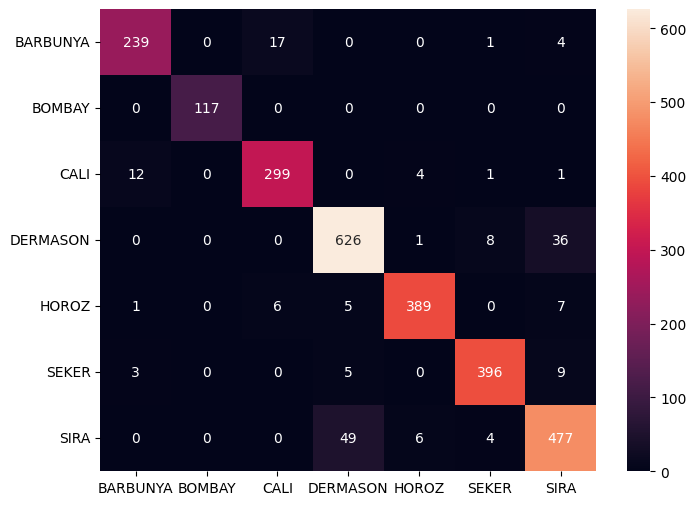

In [ ]:
model.eval() # Перевод в режим оценки
with torch.no_grad():
    test_outputs = model(X_test_t)
    _, predicted = torch.max(test_outputs, 1)

    acc = accuracy_score(y_test_t.numpy(), predicted.numpy())
    print(f'Точность (Accuracy) модели: {acc:.4f}')

# Матрица ошибок
cm = confusion_matrix(y_test_t.numpy(), predicted.numpy())
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.show()

Модель достигла точности 93% на тестовых данных. Для простой архитектуры FCNN это подтверждает высокую информативность геометрических признаков.

На матрице видно, что почти без ошибок классифицируется сорт Bombay и Seker. Основная доля ошибок сосредоточена между сортами Sira и Dermason. Возможно, данные сорта имеют схожие характеристики, и нейронной сети трудно провести между ними четкую границу. Также заметна небольшая путаница между Barbunya и Cali.

В целом, модель работает стабильно.

### Эксперимент с гиперпараметрами и архитектурой

Построим более глубокую модель: увеличим количество слоев (4 вместо 3), заменим функцию активации ReLU на Tanh (гиперболический тангенс), оптимизатор с Adam на классический SGD (градиентный спуск) с более высоким шагом обучения (lr=0.01).

In [ ]:
class DeepFCNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(DeepFCNNModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc4 = nn.Linear(hidden_dim // 2, output_dim)

        self.activation = nn.Tanh()

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.activation(self.fc3(x))
        x = self.fc4(x)
        return x

model_v2 = DeepFCNNModel(input_dim=16, hidden_dim=128, output_dim=7)
print(model_v2)
optimizer_v2 = optim.SGD(model_v2.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

DeepFCNNModel(
  (fc1): Linear(in_features=16, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=7, bias=True)
  (activation): Tanh()
)


Обучим модель и сравним график функции потерь с первой версией.

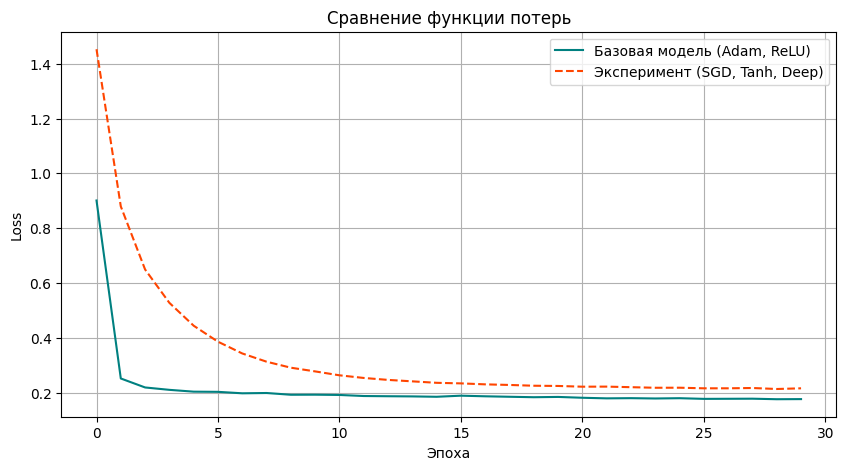

Accuracy базовой модели: 0.9339
Accuracy экспериментальной модели: 0.9291


In [ ]:
epochs = 30
history_loss_v2 = []

for epoch in range(epochs):
    model_v2.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer_v2.zero_grad()
        outputs = model_v2(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_v2.step()
        running_loss += loss.item()

    history_loss_v2.append(running_loss / len(train_loader))

# Сравнение графиков Loss
plt.figure(figsize=(10, 5))
plt.plot(history_loss, label='Базовая модель (Adam, ReLU)', color='teal')
plt.plot(history_loss_v2, label='Эксперимент (SGD, Tanh, Deep)', color='orangered', linestyle='--')
plt.title('Сравнение функции потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Расчет метрики для новой модели
model_v2.eval()
with torch.no_grad():
    preds_v2 = model_v2(X_test_t)
    _, predicted_v2 = torch.max(preds_v2, 1)
    acc_v2 = accuracy_score(y_test_t.numpy(), predicted_v2.numpy())

print(f'Accuracy базовой модели: {acc:.4f}')
print(f'Accuracy экспериментальной модели: {acc_v2:.4f}')

На графике функции потерь видно, что экспериментальная модель обучается медленнее, плавно снижая ошибку. Базовая модель достигает сходимости уже после первых эпох, а эта версия примерно после 15. Вероятно, это связано с тем, что SGD менее адаптивен, чем Adam. Также Tanh может замедлять обучение.

Точность немного упала, до 92%. Углубление сети без тщательной настройки каждого слоя привело к небольшому переобучению или деградации точности.

Таким образом, для данного типа данных избыточная сложность сети не принесла улучшений. Оптимальным решением оказалась более простая архитектура с использованием современных адаптивных алгоритмов оптимизации.

## 4. RNN

### Подготовка данных

В отличие от первого датасета, данные Air Quality представляют собой временную последовательность. Очистим их и создадим окна, так как RNN смотрит на последовательность (например, за последние 24 часа), чтобы предсказать следующее значение. В качестве целевого признака выберем концентрацию CO.

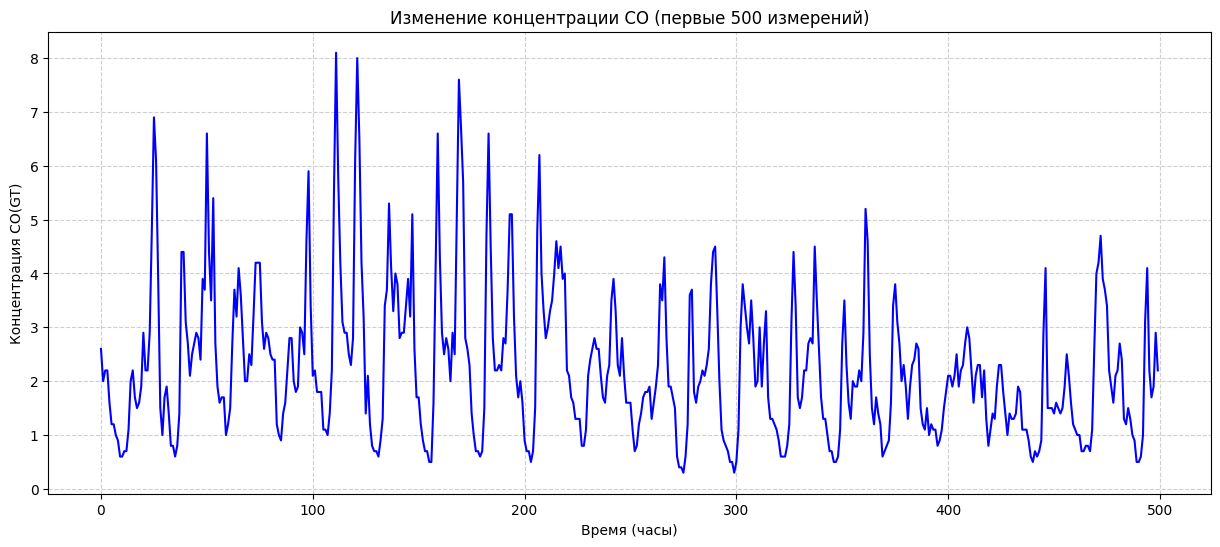

In [ ]:
df_air = pd.read_csv('AirQualityUCI.csv', sep=',', decimal=',', engine='python')

# Удаляем пустые столбцы и строки
df_air = df_air.dropna(axis=1, how='all')
df_air = df_air.dropna(axis=0, how='all')

# Убираем лишние пробелы из названий колонок
df_air.columns = [col.strip() for col in df_air.columns]

# Обработка пропусков
df_air = df_air.replace(-200, np.nan)
df_air = df_air.ffill()

data_raw = df_air['CO(GT)'].values.reshape(-1, 1)

# Визуализация
plt.figure(figsize=(15, 6))
plt.plot(df_air['CO(GT)'].values[:500], color='blue')
plt.title('Изменение концентрации CO (первые 500 измерений)')
plt.xlabel('Время (часы)')
plt.ylabel('Концентрация CO(GT)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# Нормализация
scaler_rnn = MinMaxScaler()
data_scaled = scaler_rnn.fit_transform(data)

# Создание временных окон
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X_air, y_air = create_sequences(data_scaled, 24)

# Разделение на train/test
train_size = int(len(X_air) * 0.8)
X_train_air = torch.FloatTensor(X_air[:train_size])
y_train_air = torch.FloatTensor(y_air[:train_size])
X_test_air = torch.FloatTensor(X_air[train_size:])
y_test_air = torch.FloatTensor(y_air[train_size:])

print(f"Формат входных данных для RNN: {X_train_air.shape}")

Формат входных данных для RNN: torch.Size([7466, 24, 1])


В описании данных указано, что значение -200 используется как маркер пропуска (null value). Для корректной работы нейросети заменили эти значения на NaN и восстановили методом 'ffill' (предыдущее удачное измерение копируем на место пропуска). Для нормализации использовали MinMaxScaler, который сжимает данные в диапазон [0, 1]. По графику видно, что данные считались корректно, пропуски заполнены (линия непрерывная).

Для обучения RNN данные преобразовали в окна по 24 измерения, что позволит модели учитывать суточную цикличность изменения качества воздуха. Размер тензора ([7466, 24, 1]): 7466 — количество тренировочных примеров, 24 — длина временного окна, 1 — количество признаков.

### Архитектура модели

Создадим базовую модель рекуррентнрй нейронной сети. В PyTorch для этого используется слой nn.RNN. Добавим к нему полносвязный слой в конце, чтобы предсказать одно конкретное число.

In [ ]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleRNN, self).__init__()
        # Базовая рекуррентная сеть
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        # Полносвязный слой для получения итогового прогноза
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Тензор со всеми скрытыми состояниями для каждого временного шага
        out, _ = self.rnn(x)
        # Нужно только последнее состояние последовательности (последний час из 24)
        out = self.fc(out[:, -1, :])
        return out

# Параметры модели
HIDDEN_SIZE = 64
model_rnn = SimpleRNN(input_size=1, hidden_size=HIDDEN_SIZE, output_size=1)

criterion_rnn = nn.MSELoss()
optimizer_rnn = optim.Adam(model_rnn.parameters(), lr=0.001)

print(model_rnn)

SimpleRNN(
  (rnn): RNN(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


Входной размер равен 1 (текущее значение CO), размер скрытого слоя 64 нейрона для захвата краткосрочных зависимостей. Функция потерь MSE (среднеквадратичная ошибка) выбрана потому, что мы решаем задачу регрессии, где нужно минимизировать квадрат отклонения предсказания от реальности.

### Цикл обучения и построение графика Loss

Обучим модель и построим функцию потерь.

Epoch [5/50], Loss: 0.008574
Epoch [10/50], Loss: 0.007950
Epoch [15/50], Loss: 0.007723
Epoch [20/50], Loss: 0.007233
Epoch [25/50], Loss: 0.006941
Epoch [30/50], Loss: 0.006688
Epoch [35/50], Loss: 0.006440
Epoch [40/50], Loss: 0.006218
Epoch [45/50], Loss: 0.006039
Epoch [50/50], Loss: 0.005868


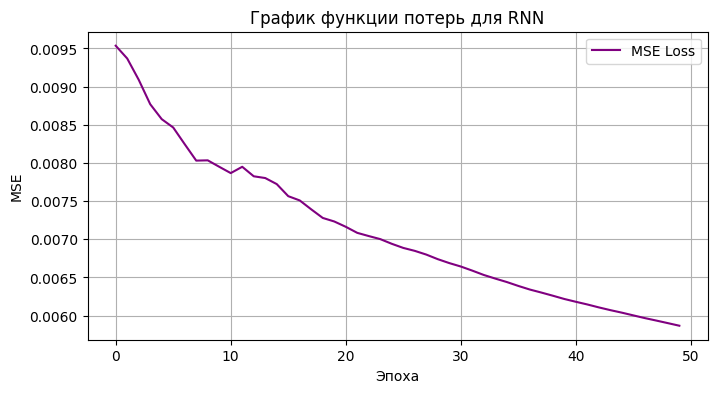

In [ ]:
epochs_rnn = 50
history_loss_rnn = []

for epoch in range(epochs_rnn):
    model_rnn.train()
    optimizer_rnn.zero_grad()

    # Прямой проход
    outputs = model_rnn(X_train_air)
    loss = criterion_rnn(outputs, y_train_air)

    # Обратный проход
    loss.backward()
    optimizer_rnn.step()

    history_loss_rnn.append(loss.item())

    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{epochs_rnn}], Loss: {loss.item():.6f}')

# График функции потерь
plt.figure(figsize=(8, 4))
plt.plot(history_loss_rnn, color='purple', label='MSE Loss')
plt.title('График функции потерь для RNN')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

График функции потерь демонстрирует экспоненциальную сходимость. На первых 10 эпохах ошибка падала быстро, дальше немного замедлилась. Отсутствие резких скачков подтверждает, что выбранный шаг обучения (lr=0.001) и оптимизатор Adam в целом подходят для этой задачи. Финальное значение MSE в районе 0.0058 указывает на то, что модель точно улавливает зависимости во временном ряду. Учитывая, что данные — это концентрация газа, такие показатели говорят о достаточно высокой предсказательной способности нейросети.

### Расчет метрики качества

Метрика качества в этой задаче - величина ошибки MSE и MAE. Расчитаем их на тестовой выборке.

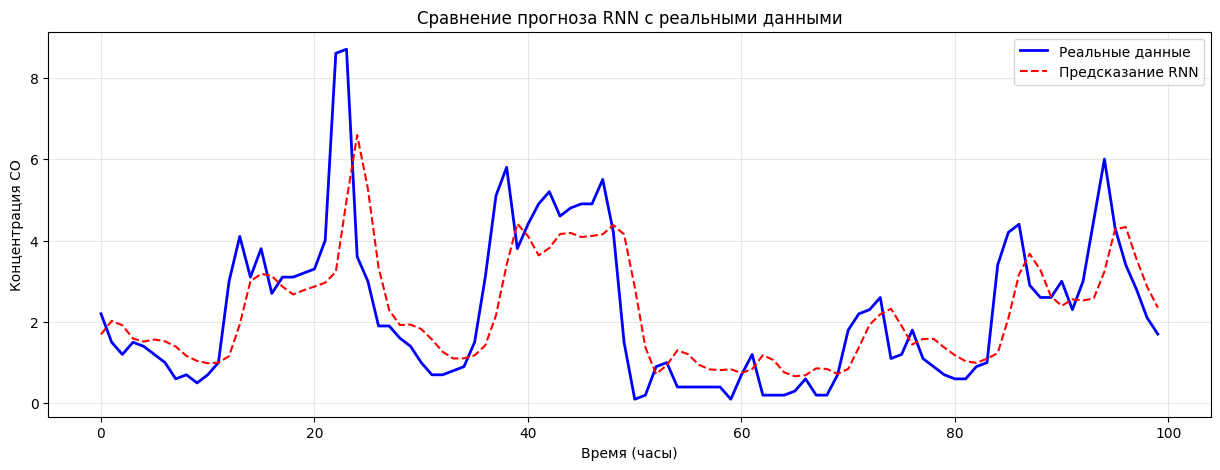

Итоговая метрика MSE на тестовых данных: 0.8900
Итоговая метрика MAE на тестовых данных: 0.6696


In [ ]:
model_rnn.eval() # режим оценки
with torch.no_grad():
    y_pred_test = model_rnn(X_test_air)

# Переводим обратно в реальные единицы измерения
y_pred_real = scaler_rnn.inverse_transform(y_pred_test.numpy())
y_true_real = scaler_rnn.inverse_transform(y_test_air.numpy())

# Визуализация первых 100 часов
plt.figure(figsize=(15, 5))
plt.plot(y_true_real[:100], label='Реальные данные', color='blue', linewidth=2)
plt.plot(y_pred_real[:100], label='Предсказание RNN', color='red', linestyle='--')
plt.title('Сравнение прогноза RNN с реальными данными')
plt.xlabel('Время (часы)')
plt.ylabel('Концентрация CO')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Итоговые метрики
final_mse = mean_squared_error(y_true_real, y_pred_real)
final_mae = mean_absolute_error(y_true_real, y_pred_real)

print(f"Итоговая метрика MSE на тестовых данных: {final_mse:.4f}")
print(f"Итоговая метрика MAE на тестовых данных: {final_mae:.4f}")

На графике сравнения (первые 100 часов теста) предсказание (красный пунктир) очень точно следует за реальными данными (синяя линия), значит модель реально понимает динамику изменения концентрации газа. Есть небольшое сглаживание на самых резких пиках.

Среднеквадратичная ошибка MSE (0.8900) меньше единицы, для данного датасета говорит о высокой точности и отсутствии грубых ошибок в прогнозе. Средняя абсолютная ошибка MAE (0.6696) показывает, что в среднем модель ошибается всего на 0.67. Учитывая, что значения CO в данных колеблются, такая погрешность является незначительной и свидетельствует о хорошем качестве обучения.

В целом, выбранная архитектура Simple RNN с окном в 24 часа справилась с задачей аппроксимации временного ряда.

### Эксперимент с гиперпараметрами и архитектурой

Поменяем архитектуру модели с простой RNN на LSTM и увеличим шаг обучения, чтобы ускорить сходимость. LSTM лучше справляется с затуханием градиента и учитывает долгосрочные связи в данных.

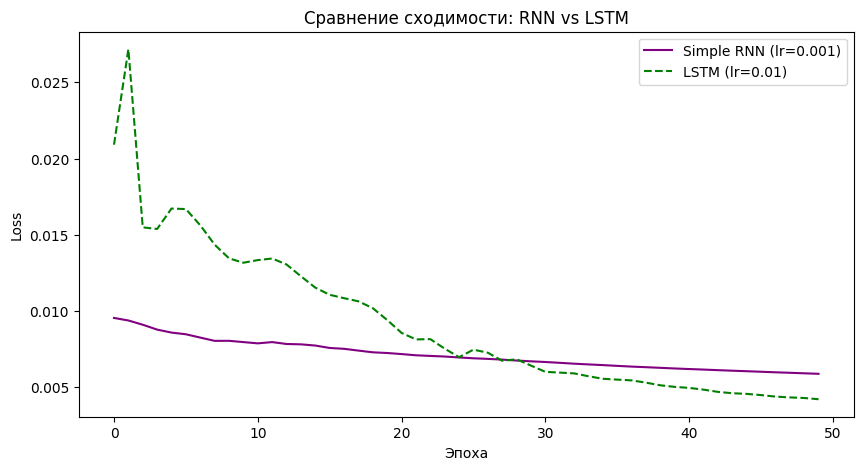

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        # Используем LSTM вместо RNN
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        # Берем только последний временной шаг
        out = self.fc(out[:, -1, :])
        return out

# Создаем модель с другими параметрами
model_lstm = LSTMModel(1, 64, 1)
# Меняем LR
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=0.01)
criterion = nn.MSELoss()

# Обучаем
history_lstm = []
for epoch in range(50):
    model_lstm.train()
    optimizer_lstm.zero_grad()
    outputs = model_lstm(X_train_air)
    loss = criterion(outputs, y_train_air)
    loss.backward()
    optimizer_lstm.step()
    history_lstm.append(loss.item())

# Сравниваем старый Loss и новый
plt.figure(figsize=(10, 5))
plt.plot(history_loss_rnn, label='Simple RNN (lr=0.001)', color='purple')
plt.plot(history_lstm, label='LSTM (lr=0.01)', color='green', linestyle='--')
plt.title('Сравнение сходимости: RNN vs LSTM')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.show()

В самом начале обучения (первые 2–3 эпохи) у LSTM виден резкий скачок ошибки вверх. Скорее всего это происходит из-за высокого Learning Rate (0.01). Почти до 25-й эпохи ошибка LSTM выше, чем у базовой RNN. После 30-й эпохи LSTM нашла верное направление и опустилась до уровня базовой модели, в итоге обогнав её по качеству.

Базовая RNN выглядит гораздо стабильнее. Маленький lr=0.001 позволил ей плавно и уверенно снижать ошибку без рывков с самой первой эпохи. Для простых временных рядов усложнение архитектуры без точного подбора гиперпараметров может привести к временному ухудшению качества обучения.

Сравним их показатели на тесте.

  Метрика  Simple RNN (lr=0.001)  LSTM (lr=0.01)
0     MSE               0.889970        0.638517
1     MAE               0.669638        0.544209


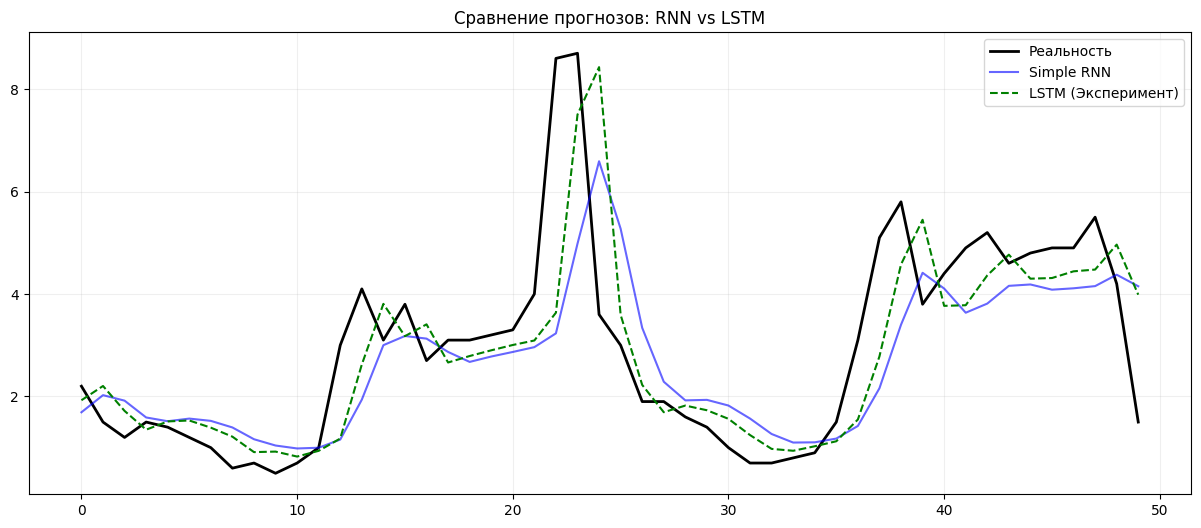

In [ ]:
model_lstm.eval()
with torch.no_grad():
    # Прогноз LSTM
    y_pred_lstm_raw = model_lstm(X_test_air)
    y_pred_lstm = scaler_rnn.inverse_transform(y_pred_lstm_raw.numpy())

# Метрики для LSTM
mse_lstm = mean_squared_error(y_true_real, y_pred_lstm)
mae_lstm = mean_absolute_error(y_true_real, y_pred_lstm)

# Сравнительная таблица
results = pd.DataFrame({
    'Метрика': ['MSE', 'MAE'],
    'Simple RNN (lr=0.001)': [final_mse, final_mae],
    'LSTM (lr=0.01)': [mse_lstm, mae_lstm]
})
print(results)

# Визуальное сравнение прогнозов (первые 50 часов)
plt.figure(figsize=(15, 6))
plt.plot(y_true_real[:50], label='Реальность', color='black', linewidth=2)
plt.plot(y_pred_real[:50], label='Simple RNN', color='blue', alpha=0.6)
plt.plot(y_pred_lstm[:50], label='LSTM (Эксперимент)', color='green', linestyle='--')
plt.title('Сравнение прогнозов: RNN vs LSTM')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

На тестовых данных модель LSTM показала превосходство. Ошибки значительно снизились, MSE с 0.8900 до 0.6385, MAE с 0.6696 до 0.5442. Предсказание стало точнее. Большая разница в MSE говорит о том, что LSTM гораздо реже допускает грубые ошибки при прогнозе резких скачков концентрации CO.

На графике видно, что LSTM гораздо точнее повторяет черную линию реальных данных, особенно в моменты резких спадов и подъемов. Базовая RNN сильнее сглаживает, не успевая за быстрыми изменениями.

Эксперимент показал, что для временных рядов архитектура LSTM является более подходящей, даже если процесс обучения выглядит менее стабильным в начале.

## 5. CNN

### Подготовка данных

Картинки в датасете могут быть разного размера, яркости и ориентации. Нейросеть ожидает на вход четко заданный тензор, поэтому приводим все фото к одному размеру, переводим пиксели из формата 0-255 в тензоры PyTorch (0-1) и нормализуем их. Для создания датасета используем ImageFolder, который сам понимает названия классов. Делим данные на группы (батчи) по 32 картинки и перемешиваем тренировочные данные, чтобы сеть не привыкала к порядку, а училась обобщать.

In [ ]:
!unzip -q archive.zip

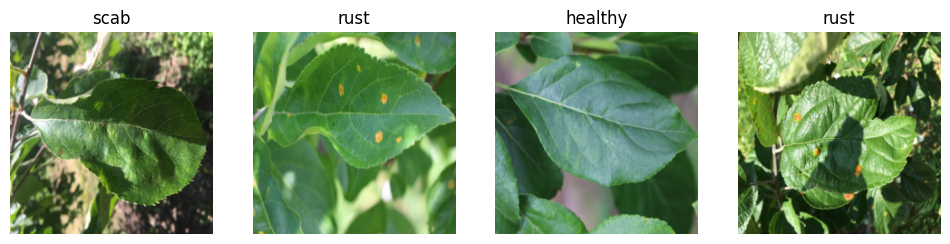

Классы в датасете: ['healthy', 'rust', 'scab']
Всего изображений: 1730


In [ ]:
# Трансформации
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Загрузка данных
data_path = 'data'
full_dataset = datasets.ImageFolder(root=data_path, transform=transform)

# Разделение на train и test
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_data, test_data = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# Визуализация нескольких примеров
def imshow(img):
    # Переводим из тензора в numpy
    img = img.numpy().transpose((1, 2, 0))
    # Обратная нормализация
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)

classes = full_dataset.classes
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(4):
    plt.subplot(1, 4, i+1)
    imshow(images[i])
    plt.title(classes[labels[i]])
    plt.axis('off')
plt.show()

print(f"Классы в датасете: {classes}")
print(f"Всего изображений: {len(full_dataset)}")

Загружено 1730 изображений, распределенных по трем классам: healthy, rust, scab. Выборочная проверка батча показала, что метки классов соответствуют изображениям. Визуально классы rust и scab различаются типом и цветом пятен на листе, что дает модели базу для извлечения признаков.

### Архитектура модели

Построим классическую CNN, которая состоит из чередования сверточных слоев, слоев пулинга и полносвязных слоев.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Сверточный блок 1: ищем простые признаки (линии, края)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Сверточный блок 2: более сложные формы (пятна, текстуру)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        # Сверточный блок 3: глубокие признаки
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # Полносвязные слои
        self.fc1 = nn.Linear(64 * 28 * 28, 512) # После трех MaxPool 224x224 превращается в 28x28
        self.fc2 = nn.Linear(512, 3) # На выходе 3 класса (healthy, rust, scab)
        self.dropout = nn.Dropout(0.2) # Защита от переобучения

    def forward(self, x):
        # Пропускаем через свертки с активацией ReLU и пулингом
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        # Выравниваем многомерный тензор в вектор для полносвязного слоя
        x = x.view(-1, 64 * 28 * 28)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model_cnn = SimpleCNN()

# Переносим на GPU (на CPU обучение дольше)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cnn = model_cnn.to(device)

print(model_cnn)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=50176, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=3, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


Сверточные слои: каждый фильтр проходит по изображению и ищет специфические паттерны. Функция активации ReLU добавляет нелинейность. Пулинг MaxPool2d берет максимальное значение из окна 2x2, уменьшая размер изображения, что помогает модели стать устойчивой к небольшим сдвигам объекта. Дропаут случайно выключает 20% нейронов во время обучения, заставляя сеть не полагаться на конкретные пиксели, а искать общие закономерности. Полносвязные слои Linear на основе всех найденных признаков принимают окончательное решение, к какому из классов относится лист.

### Цикл обучения и построение графика Loss

Будем отслеживать сразу две метрики: Loss (насколько сильно ошибается модель) и Accuracy (какой процент картинок угадала).

Эпоха [1/15] | Loss: 1.2387 | Acc: 37.93%
Эпоха [2/15] | Loss: 1.0529 | Acc: 43.79%
Эпоха [3/15] | Loss: 0.9972 | Acc: 50.22%
Эпоха [4/15] | Loss: 0.9605 | Acc: 53.47%
Эпоха [5/15] | Loss: 0.8766 | Acc: 60.12%
Эпоха [6/15] | Loss: 0.7017 | Acc: 69.80%
Эпоха [7/15] | Loss: 0.4512 | Acc: 82.01%
Эпоха [8/15] | Loss: 0.2002 | Acc: 92.99%
Эпоха [9/15] | Loss: 0.0801 | Acc: 97.33%
Эпоха [10/15] | Loss: 0.0353 | Acc: 98.92%
Эпоха [11/15] | Loss: 0.0222 | Acc: 99.42%
Эпоха [12/15] | Loss: 0.0131 | Acc: 99.78%
Эпоха [13/15] | Loss: 0.0075 | Acc: 100.00%
Эпоха [14/15] | Loss: 0.0054 | Acc: 99.86%
Эпоха [15/15] | Loss: 0.0023 | Acc: 100.00%


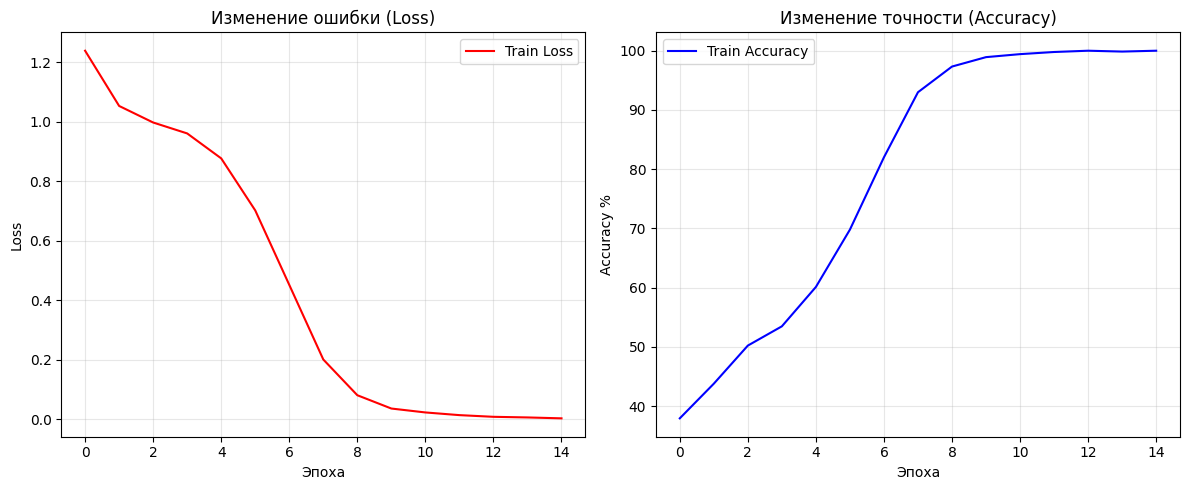

In [ ]:
# Настройка обучения
criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=0.001)

epochs_cnn = 15
history_loss_cnn = []
history_acc_cnn = []

for epoch in range(epochs_cnn):
    model_cnn.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        # Перенос данных на GPU
        images, labels = images.to(device), labels.to(device)

        # Обнуляем градиенты
        optimizer_cnn.zero_grad()

        # Прямой проход
        outputs = model_cnn(images)
        loss = criterion_cnn(outputs, labels)

        # Обратный проход
        loss.backward()
        optimizer_cnn.step()

        running_loss += loss.item()

        # Считаем точность в процессе
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    history_loss_cnn.append(epoch_loss)
    history_acc_cnn.append(epoch_acc)

    print(f'Эпоха [{epoch+1}/{epochs_cnn}] | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_loss_cnn, color='red', label='Train Loss')
plt.title('Изменение ошибки (Loss)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_acc_cnn, color='blue', label='Train Accuracy')
plt.title('Изменение точности (Accuracy)')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy %')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Первые эпохи (1–5) модель обучалась постепенно. Точность росла с 37.93% до 60.12%. Веса сверточных слоев настраивались на базовые признаки. На эпохах 6–8 произошел резкий качественный скачок. Ошибка упала с 0.7017 до 0.2002, а точность выросла до 92.99%. Это говорит о том, что сеть успешно подобрала комбинацию фильтров, позволяющую четко отделять признаки болезней листьев. На эпохи 13–15 модель вышла на плато, достигнув точности в 100%.

Такая высокая точность на тренировочных данных часто указывает на переобучение. Модель просто запомнила конкретные картинки, а не выучила общие признаки болезней. Возможно это произошло потому, что датасет относительно небольшой и довольно мощная для такой задачи сеть.

Проверим это на тестовой выборке.

### Расчет метрики качества

Прогоним тестовые изображения через модель и посчитает итоговый процент успеха. В задачах классификации изображений главной метрикой является Accuracy.

Итоговая точность на тестовой выборке: 44.22%


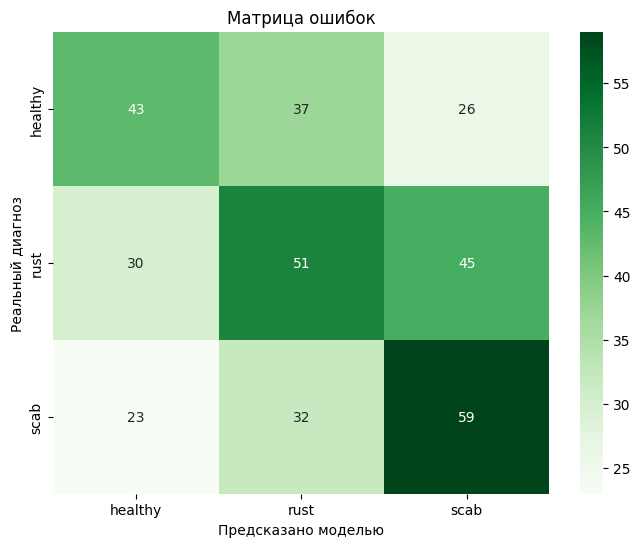


Отчет по классам:
              precision    recall  f1-score   support

     healthy       0.45      0.41      0.43       106
        rust       0.42      0.40      0.41       126
        scab       0.45      0.52      0.48       114

    accuracy                           0.44       346
   macro avg       0.44      0.44      0.44       346
weighted avg       0.44      0.44      0.44       346



In [ ]:
model_cnn.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_cnn(images)
        _, predicted = torch.max(outputs, 1)

        # Собираем предсказания и реальные метки
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Общая точность
correct = sum(np.array(all_preds) == np.array(all_labels))
total = len(all_labels)
test_accuracy = 100 * correct / total

print(f"Итоговая точность на тестовой выборке: {test_accuracy:.2f}%")

# Матрица ошибок
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Предсказано моделью')
plt.ylabel('Реальный диагноз')
plt.title('Матрица ошибок')
plt.show()

print("\nОтчет по классам:")
print(classification_report(all_labels, all_preds, target_names=classes))

Результат на тестовых данных подтверждает сильное переобучение. Точность 44% для трех классов, чуть лучше, чем случайное угадывание (33%). Модель не выделила признаки пятен или цвета, она запомнила шум, фон или конкретное расположение пикселей, которое было только в данных train.

На матрице ошибки распределены почти равномерно. Это говорит о том, что для модели все картинки информационный шум, в котором она пытается найти знакомые по памяти детали.

Все метрики очень низкие, нет класса, который модель бы выделила уверенно. F1-score в районе 0.41-0.48 подтверждает, что модель ошибается одинаково часто во всех категориях.

Модель слишком сложна для текущего объема данных или данные слишком однообразны.

### Эксперимент с гиперпараметрами и архитектурой

В сверточных сетях есть два классических пути улучшения: добавить слоев (сделать сеть глубже) или использовать Data Augmentation (искусственно увеличить датасет). В данных довольно мало изображений для нейросети, поэтому в эксперименте применим аугментацию. Добавим RandomHorizontalFlip (отражение), RandomRotation (поворот) и ColorJitter (изменение яркости/контраста). Это заставит модель искать именно признаки болезни, а не привязываться к ракурсу. Также, добавим еще один сверточный блок, чтобы сеть могла уловить более тонкие детали пятен.

In [ ]:
# Новые трансформации с аугментацией
train_transform_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # Случайное отражение
    transforms.RandomRotation(15),           # Поворот на 15 градусов
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Изменение света
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Пересоздаем тренировочный загрузчик с аугментацией
train_data.dataset.transform = train_transform_aug
train_loader_aug = DataLoader(train_data, batch_size=32, shuffle=True)

# Улучшенная модель
class AdvancedAppleCNN(nn.Module):
    def __init__(self):
        super(AdvancedAppleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.4), # Увеличим dropout для борьбы с переобучением
            nn.Linear(512, 3)
        )

    def forward(self, x):
        return self.fc(self.conv_layers(x))

model_advanced = AdvancedAppleCNN().to(device)
# Снизим LR для более тонкой настройки
optimizer_aug = torch.optim.Adam(model_advanced.parameters(), lr=0.0005)

Обучим модель и сравним графики Loss.

Эпоха [1/15] | Loss: 1.0998 | Acc: 34.54%
Эпоха [2/15] | Loss: 1.0665 | Acc: 43.79%
Эпоха [3/15] | Loss: 0.9533 | Acc: 55.49%
Эпоха [4/15] | Loss: 0.6399 | Acc: 73.84%
Эпоха [5/15] | Loss: 0.4929 | Acc: 77.10%
Эпоха [6/15] | Loss: 0.4339 | Acc: 79.91%
Эпоха [7/15] | Loss: 0.3930 | Acc: 81.94%
Эпоха [8/15] | Loss: 0.3824 | Acc: 83.45%
Эпоха [9/15] | Loss: 0.3379 | Acc: 84.39%
Эпоха [10/15] | Loss: 0.3211 | Acc: 85.91%
Эпоха [11/15] | Loss: 0.3119 | Acc: 85.98%
Эпоха [12/15] | Loss: 0.2790 | Acc: 88.37%
Эпоха [13/15] | Loss: 0.2418 | Acc: 90.03%
Эпоха [14/15] | Loss: 0.2005 | Acc: 92.05%
Эпоха [15/15] | Loss: 0.1605 | Acc: 93.86%


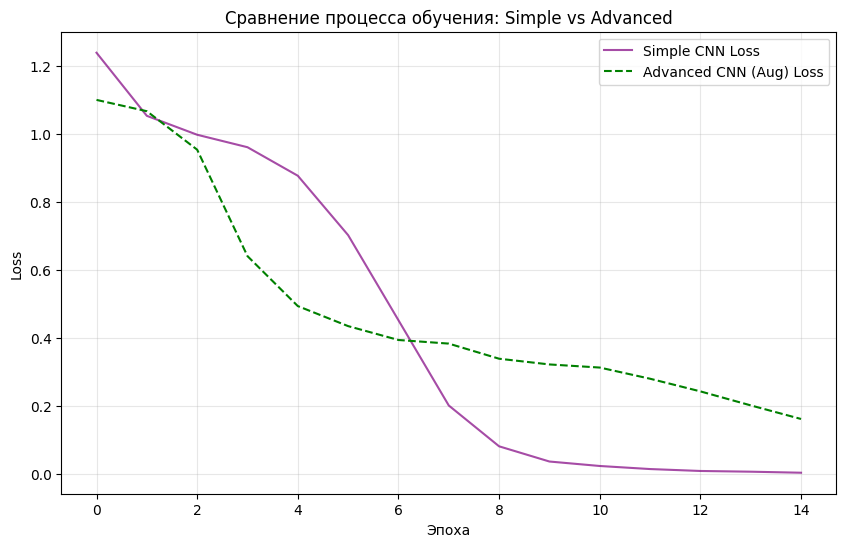

In [ ]:
history_loss_adv = []
history_acc_adv = []

for epoch in range(15):
    model_advanced.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_aug: # загрузчик с аугментацией
        images, labels = images.to(device), labels.to(device)
        optimizer_aug.zero_grad()
        outputs = model_advanced(images)
        loss = criterion_cnn(outputs, labels)
        loss.backward()
        optimizer_aug.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    history_loss_adv.append(running_loss / len(train_loader_aug))
    history_acc_adv.append(100 * correct / total)
    print(f'Эпоха [{epoch+1}/15] | Loss: {history_loss_adv[-1]:.4f} | Acc: {history_acc_adv[-1]:.2f}%')

plt.figure(figsize=(10, 6))
plt.plot(history_loss_cnn, label='Simple CNN Loss', color='purple', alpha=0.7)
plt.plot(history_loss_adv, label='Advanced CNN (Aug) Loss', color='green', linestyle='--')
plt.title('Сравнение процесса обучения: Simple vs Advanced')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Ошибка новой модели падает гораздо медленнее и плавнее. Это происходит потому, что из-за аугментации модель каждую эпоху видит немного разные картинки. Ей сложнее учиться, она не может просто запомнить пиксели и приходится реально искать признаки. Точность также растет плавнее, без сильных скачков, на 15-й эпохе не 100%, а 93.86%.

Архитектура с дополнительными слоями и увеличенным Dropout работает более устойчиво.


Сравним итоговые результаты на тесте.

In [ ]:
model_advanced.eval()
adv_preds, adv_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_advanced(images)
        _, predicted = torch.max(outputs, 1)
        adv_preds.extend(predicted.cpu().numpy())
        adv_labels.extend(labels.cpu().numpy())

# Расчет точности для Advanced
acc_adv_test = 100 * (np.array(adv_preds) == np.array(adv_labels)).sum() / len(adv_labels)

comparison_df = pd.DataFrame({
    'Модель': ['Simple CNN', 'Advanced CNN + Aug'],
    'Accuracy на тесте (%)': [test_accuracy, acc_adv_test] # test_accuracy мы считали раньше
})

print(comparison_df)

               Модель  Accuracy на тесте (%)
0          Simple CNN              44.219653
1  Advanced CNN + Aug              93.063584


Advanced CNN достигла точности 93.06% на тестовых данных, практически идеальный классификатор. Точность выросла более чем в два раза, по сравнению с первой моделью. Это доказывает, что новая модель действительно научилась различать болезни яблони, а не просто запомнила фон.

Повороты и искажения заставили сеть сфокусироваться на главных признаках — цвете и форме поражений. Дополнительный сверточный слой позволил выделить более сложные текстуры, которые пропускала простая модель. Дропаут не дал нейронам заучить конкретные пиксели, заставляя каждый слой работать на обобщение.

Для задач компьютерного зрения на малых датасетах полезно использование методов расширения выборки, которые препятствуют запоминанию данных и способствуют формированию устойчивых признаков для классификации.

## Вывод

В ходе выполнения данной работы было проведено исследование современных архитектур нейронных сетей для решения различных типов задач.

1. Полносвязные сети. Работа с FCNN показала, что это лучший выбор для структурированных табличных данных. В ходе экспериментов стало ясно, что слишком простая сеть не видит зависимости в данных, а слишком глубокая может работать нестабильно.
2. Рекуррентные сети. Эксперименты с временными рядами показали проблему забывчивости простых RNN. Переход к архитектуре LSTM позволил модели учитывать прошлые события, что важно для данных, где текущее значение напрямую зависит от предыдущих. Это подтвердилось снижением ошибки на графиках.
3. Сверточные сети (CNN). Простая модель идеально выучила тренировочные фото, но провалилась на тесте. Это на практике показало переобучение. Улучшенная модель с аугментацией позволила поднять точность до 93%. Сверточным слоям нужна качественная и разнообразная выборка.

Проведенные эксперименты позволили на практике изучить работу нейросетей, диагностировать проблемы и исправить их. Работа показывает, что успех глубокого обучения зависит не только от выбора архитектуры, но и от грамотной настройки процесса обучения.